# Feishu portfolio-management backtest

A **simple, cross-sectional long–short backtest**: each trading day, rank all
assets by a model's signal, go long the top / short the bottom, dollar-neutral,
rebalanced daily. This is the standard portfolio-management framing for a
stock universe (as opposed to a single-asset trading backtest).

**Protocol** (matches the model's own label, so it is directly tradeable):
- Signal per (asset, day): `score = P(up) − P(down)`.
- Weight: cross-sectionally demeaned score (dollar-neutral, gross exposure 1).
- Return per day: `Σ wᵢ·rᵢ`, where `rᵢ` is the label's realized forward return
  `(close_{t+1} − vwap_t)/|vwap_t|` (enter at next-day's morning VWAP, exit at
  the following close — exactly what the model's label thresholds).
- Cost: half the round-trip `COST_BPS` charged on daily turnover `Σ|Δw|`.

**Metrics**: annualized net return / vol / Sharpe, max drawdown, daily hit
rate, turnover, and the mean cross-sectional **Information Coefficient** (rank
correlation of signal vs. forward return) — the standard portfolio-management
signal-quality diagnostic.

> **Caveats.** This is a cost *model*, not an execution simulation (no market
> impact, no partial fills). The test period is short (the last ~15% of
> in-sample trading days) and the universe is a handful of assets — read
> **relative rankings across models**, not absolute return levels, as the
> reliable output.

> Run from the **Penny repo root** so `data/stocks/feishu` and `checkpoints/`
> resolve.

## 1. Setup

In [16]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as Fn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")


def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "src").is_dir():
            return p
    raise RuntimeError(f"could not find Penny repo root above {start}")


REPO = _find_repo_root(Path.cwd())
os.chdir(REPO)
sys.path.insert(0, str(REPO / "src"))
print("repo root:", REPO)

from stocks.feishu.dataset import LOBDataset  # noqa: E402
from stocks.feishu.build import (  # noqa: E402
    _VAL_CUM,
    _asset_ranges,
    _build_feature_matrix,
)
from stocks.feishu.labels import compute_forward_returns  # noqa: E402
from models.deeplob import DeepLOB  # noqa: E402
from models.ctabl import CTABL  # noqa: E402
from models.dla import DLA  # noqa: E402
from models.tlob import TLOB  # noqa: E402
from models.linvar import LinVAR  # noqa: E402
from models.logreg import LogReg  # noqa: E402
from models.jumpgatelob import JumpGateLOB  # noqa: E402
from models.alphastablelob import AlphaStableLOB  # noqa: E402

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

repo root: /Users/arshia/Projects/Personal/Penny
device: cpu


## 2. Config & checkpoint registry

`VARIANT` selects which trained runs to load: `"20_assets"` (models trained on
the 20 high-volume assets — uniform + noisy groups) or `"all"` (whole
universe). `SYMBOLS` is the asset universe the backtest is built over.

In [17]:
BATCH = 256
VARIANT = "20_assets"           # "20_assets" | "all"
TRADING_DAYS = 242               # A-share year, for annualisation
COST_BPS = 10.0                  # round-trip cost charged on daily turnover

# high-volume asset groups (from the volume / trading-uniformity analysis)
UNIFORM_10 = ["A002059", "A001750", "A000863", "A000369", "A001402",
              "A001472", "A001351", "A001438", "A000956", "A000613"]
NOISY_10 = ["A002000", "A000295", "A001748", "A002042", "A000400",
            "A000875", "A000452", "A001208", "A002142", "A001663"]
SYMBOLS = UNIFORM_10 + NOISY_10

MODELS = {
    "logreg": LogReg, "linvar": LinVAR, "deeplob": DeepLOB, "ctabl": CTABL,
    "dla": DLA, "tlob": TLOB, "jumpgatelob": JumpGateLOB,
    "alphastablelob": AlphaStableLOB,
}
DISPLAY = {m: m for m in MODELS}
CKPT_ROOT = REPO / "checkpoints" / "stocks" / "feishu"


def discover_checkpoints():
    found = {}
    for tag in MODELS:
        d = CKPT_ROOT / tag
        if not d.exists():
            continue
        runs = sorted(
            p for p in d.iterdir()
            if p.is_dir() and p.name.endswith(VARIANT) and (p / "best.pt").exists()
        )
        if runs:
            found[tag] = runs[-1]
    return found


CHECKPOINTS = discover_checkpoints()
print(f"variant={VARIANT}  |  {len(SYMBOLS)} assets  |  discovered checkpoints:")
for tag in MODELS:
    hit = CHECKPOINTS.get(tag)
    print(f"  {tag:<16} {'OK ' + hit.name if hit else '-- missing'}")

variant=20_assets  |  20 assets  |  discovered checkpoints:
  logreg           OK logreg_ofi_20_assets
  linvar           OK linvar_ofi_20_assets
  deeplob          OK deeplob_ofi_20_assets
  ctabl            OK ctabl_ofi_20_assets
  dla              OK dla_ofi_20_assets
  tlob             OK tlob_ofi_20_assets
  jumpgatelob      OK jumpgatelob_levy_ofi_20_assets
  alphastablelob   OK alphastablelob_joint_a1.5_ofi_20_assets


## 3. Build the backtest frame

Reuses `_build_feature_matrix` (the exact feature pipeline every model was
trained on) for the raw window tensor, and locally attaches each test
window's **entry date** and **continuous forward return** — the same
`(close_{t+1} − vwap_t)/|vwap_t|` quantity the label thresholds, recomputed
directly from the daily file so the backtest is self-contained. The test
slice (last 15% of each asset's trading days) mirrors `build_datasets_multi`
exactly, so results are on the same held-out period the models were
evaluated on.

In [18]:
def build_backtest_frame(config, data_dir, symbols):
    """(test_ds, bt_df): bt_df row i <-> the i-th window a shuffle=False loader
    over test_ds yields, with columns asset_idx/asset/date/fwd_ret/label."""
    T = config["T_past"]
    feat, row_labels, row_asset, nf, ordered_syms = _build_feature_matrix(
        config, data_dir, symbols
    )

    root = Path(data_dir).resolve()
    daily = pd.read_parquet(root / config.get("daily_file", "daily_data_in_sample.parquet"))
    daily = daily.rename(columns={"trade_day_id": "date"})
    daily["date"] = daily["date"].astype(str)
    daily = daily[daily["asset_id"].isin(set(ordered_syms))]
    per_sym = {s: g.sort_values("date").reset_index(drop=True)
              for s, g in daily.groupby("asset_id", sort=True)}

    n_rows = len(row_asset)
    row_date = np.empty(n_rows, dtype=object)
    row_fwd = np.full(n_rows, np.nan, dtype=np.float64)
    ptr = 0
    for sym in ordered_syms:  # same per-asset order as _build_feature_matrix
        g = per_sym[sym]
        nd = len(g)
        row_date[ptr:ptr + nd] = g["date"].to_numpy()
        row_fwd[ptr:ptr + nd] = compute_forward_returns(g).to_numpy()
        ptr += nd
    assert ptr == n_rows, f"row layout mismatch: {ptr} vs {n_rows}"

    rows = []
    for lo, hi in _asset_ranges(row_asset):
        starts = [s for s in range(lo, hi - T) if row_labels[s + T] >= 0]
        if not starts:
            continue
        n_val = int(_VAL_CUM * len(starts))
        for s in starts[n_val:]:  # test slice, same cut as build_datasets_multi
            drow = s + T
            rows.append({
                "start": s, "asset_idx": int(row_asset[s]),
                "asset": ordered_syms[int(row_asset[s])],
                "date": row_date[drow], "fwd_ret": float(row_fwd[drow]),
                "label": int(row_labels[drow]),
            })
    bt_df = pd.DataFrame(rows)
    test_ds = LOBDataset(feat, bt_df["start"].to_numpy(np.int64), row_labels, T,
                         row_asset=row_asset)
    return test_ds, bt_df


# base config shared by every checkpoint variant (T_past/alpha/n_features identical)
assert CHECKPOINTS, "no checkpoints discovered — check VARIANT/CKPT_ROOT"
_base = torch.load(next(iter(CHECKPOINTS.values())) / "best.pt",
                   map_location=DEVICE, weights_only=False)["config"].copy()
_base["batch_size"] = BATCH
DATA_DIR = _base["data_dir"]
print(f"T_past={_base['T_past']}  alpha={_base['alpha']}  data_dir={DATA_DIR}")

TEST_DS, BT = build_backtest_frame(_base, DATA_DIR, SYMBOLS)
print(f"test windows: {len(TEST_DS)}  |  trading days: {BT['date'].nunique()}  "
      f"({BT['date'].min()} -> {BT['date'].max()})")
BT.head()

2026-07-20 15:30:27.700 | INFO     | stocks.feishu.build:_build_feature_matrix:144 - building feishu features (RAM) mode=OFI nf=259


T_past=50  alpha=0.015  data_dir=data/stocks/feishu


2026-07-20 15:31:13.451 | INFO     | stocks.feishu.build:_build_feature_matrix:254 - feishu features built (in RAM): 9,680 rows × 259 feat


test windows: 1300  |  trading days: 65  (D419 -> D483)


,start,asset_idx,asset,date,fwd_ret,label
0,368,0,A002059,D419,-0.0090,1
1,369,0,A002059,D420,0.0133,1
2,370,0,A002059,D421,0.0339,2
3,371,0,A002059,D422,0.0176,2
4,372,0,A002059,D423,0.0120,1


## 4. Score every model

In [19]:
@torch.no_grad()
def score_windows(model):
    model.eval()
    loader = DataLoader(TEST_DS, batch_size=BATCH, shuffle=False)
    scores, preds = [], []
    for b in loader:
        p = Fn.softmax(model.predict(b, DEVICE), dim=1).cpu().numpy()
        scores.append(p[:, 2] - p[:, 0])
        preds.append(p.argmax(1))
    return np.concatenate(scores), np.concatenate(preds)


SCORES = {}
for tag, cls in MODELS.items():
    hit = CHECKPOINTS.get(tag)
    if not hit:
        print(f"  {tag:<16} -- no checkpoint, skipped")
        continue
    ckpt = torch.load(hit / "best.pt", map_location=DEVICE, weights_only=False)
    model = cls(ckpt["config"]).to(DEVICE)
    model.load_state_dict(ckpt["model"])
    s, p = score_windows(model)
    SCORES[tag] = (s, p)
    print(f"  {tag:<16} scored  (score range [{s.min():+.3f}, {s.max():+.3f}])")
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
print(f"\nscored {len(SCORES)} models")

  logreg           scored  (score range [-0.852, +0.895])
  linvar           scored  (score range [-0.634, +0.579])
  deeplob          scored  (score range [-0.011, +0.011])
  ctabl            scored  (score range [-0.426, +0.479])
  dla              scored  (score range [-0.035, -0.035])
  tlob             scored  (score range [+0.011, +0.094])
  jumpgatelob      scored  (score range [-0.079, +0.047])
  alphastablelob   scored  (score range [-0.189, +0.150])

scored 8 models


## 5. Portfolio engine

Daily cross-sectional dollar-neutral long–short: weight ∝ demeaned score,
gross exposure normalised to 1, half the round-trip cost charged on turnover.

Alongside every model we also compute an **equal-weighted market index** (long-only, 1/N in every asset in the universe, same cost model) as the passive benchmark: a model only adds value if it beats *this*, not just zero.

In [20]:
def portfolio(bt, score, pred, cost_bps=COST_BPS):
    df = bt.assign(score=score, pred=pred).dropna(subset=["fwd_ret", "score"])
    daily, prev = [], pd.Series(dtype=float)
    for d in sorted(df["date"].unique()):
        g = df[df["date"] == d]
        s = g.set_index("asset")["score"]
        r = g.set_index("asset")["fwd_ret"]
        w = s - s.mean()                                  # dollar-neutral tilt
        gross_exp = w.abs().sum()
        if gross_exp > 0:
            w = w / gross_exp                              # gross exposure = 1
        r_gross = float((w * r).sum())
        idx = w.index.union(prev.index)
        turnover = float(
            (w.reindex(idx, fill_value=0.0) - prev.reindex(idx, fill_value=0.0))
            .abs().sum()
        )
        r_net = r_gross - 0.5 * (cost_bps / 1e4) * turnover
        ic = (float(pd.Series(s.values).corr(pd.Series(r.values), method="spearman"))
              if len(s) >= 3 else np.nan)
        daily.append({"date": d, "gross": r_gross, "net": r_net,
                      "turnover": turnover, "ic": ic, "n": len(g)})
        prev = w
    return pd.DataFrame(daily)


def perf(daily):
    if daily.empty:
        return {}
    net = daily["net"].to_numpy()
    sd = net.std(ddof=1)
    cum = np.cumsum(net)
    dd = float((np.maximum.accumulate(cum) - cum).max())
    return {
        "days": len(net),
        "ann_return_%": net.mean() * TRADING_DAYS * 100,
        "ann_vol_%": sd * np.sqrt(TRADING_DAYS) * 100,
        "sharpe": (net.mean() / sd * np.sqrt(TRADING_DAYS)) if sd > 0 else np.nan,
        "max_dd_%": dd * 100,
        "hit_%": (net > 0).mean() * 100,
        "turnover": daily["turnover"].mean(),
        "mean_IC": daily["ic"].mean(),
        "net_bp/day": net.mean() * 1e4,
    }


CURVES, ROWS = {}, []
for tag, (score, pred) in SCORES.items():
    daily = portfolio(BT, score, pred)
    CURVES[tag] = daily
    ROWS.append({"model": DISPLAY[tag], **perf(daily)})
    print(f"  {tag:<16} Sharpe={perf(daily)['sharpe']:+.2f}")

summary = pd.DataFrame(ROWS).set_index("model").sort_values("sharpe", ascending=False)

  logreg           Sharpe=-5.77
  linvar           Sharpe=-0.38
  deeplob          Sharpe=+0.23
  ctabl            Sharpe=-0.75
  dla              Sharpe=+4.15
  tlob             Sharpe=+2.40
  jumpgatelob      Sharpe=+0.94
  alphastablelob   Sharpe=+0.41


In [21]:
def equal_weight_index(bt, cost_bps=COST_BPS):
    """Passive benchmark: long-only, equal-weight (1/N) every asset in the
    universe each day, rebalanced daily, same turnover-based cost model as the
    model portfolios. No IC (there is no cross-sectional signal to score)."""
    df = bt.dropna(subset=["fwd_ret"])
    daily, prev = [], pd.Series(dtype=float)
    for d in sorted(df["date"].unique()):
        g = df[df["date"] == d]
        r = g.set_index("asset")["fwd_ret"]
        w = pd.Series(1.0 / len(r), index=r.index)         # equal weight, long-only
        r_gross = float((w * r).sum())
        idx = w.index.union(prev.index)
        turnover = float(
            (w.reindex(idx, fill_value=0.0) - prev.reindex(idx, fill_value=0.0))
            .abs().sum()
        )
        r_net = r_gross - 0.5 * (cost_bps / 1e4) * turnover
        daily.append({"date": d, "gross": r_gross, "net": r_net,
                      "turnover": turnover, "ic": np.nan, "n": len(g)})
        prev = w
    return pd.DataFrame(daily)


BENCH_TAG = "equal_weight_index"
CURVES[BENCH_TAG] = equal_weight_index(BT)
ROWS.append({"model": BENCH_TAG, **perf(CURVES[BENCH_TAG])})
summary = pd.DataFrame(ROWS).set_index("model").sort_values("sharpe", ascending=False)
print(f"  {BENCH_TAG:<16} Sharpe={perf(CURVES[BENCH_TAG])['sharpe']:+.2f}  "
      f"(passive long-only benchmark)")

  equal_weight_index Sharpe=-2.51  (passive long-only benchmark)


## 6. Results

In [22]:
print(f"=== summary (sorted by net Sharpe, {COST_BPS:.0f}bp cost) ===")
display(summary.style.background_gradient(cmap="RdYlGn", subset=["sharpe", "mean_IC"])
        .format({"days": "{:.0f}", "ann_return_%": "{:.1f}", "ann_vol_%": "{:.1f}",
                 "sharpe": "{:.2f}", "max_dd_%": "{:.1f}", "hit_%": "{:.0f}",
                 "turnover": "{:.2f}", "mean_IC": "{:.3f}", "net_bp/day": "{:.2f}"}))

=== summary (sorted by net Sharpe, 10bp cost) ===


,days,ann_return_%,ann_vol_%,sharpe,max_dd_%,hit_%,turnover,mean_IC,net_bp/day
model,,,,,,,,,
dla,65,81.7,19.7,4.15,5.3,63,0.43,0.106,33.78
tlob,65,32.6,13.6,2.40,5.4,57,1.39,0.057,13.46
jumpgatelob,65,12.5,13.3,0.94,5.2,49,0.18,0.035,5.15
alphastablelob,65,6.5,16.1,0.41,5.2,51,0.36,0.019,2.70
deeplob,65,2.9,12.7,0.23,8.2,51,0.76,0.019,1.19
linvar,65,-6.0,15.7,-0.38,6.7,42,1.39,-0.038,-2.47
ctabl,65,-10.5,13.9,-0.75,10.4,45,1.35,-0.029,-4.32
equal_weight_index,65,-66.0,26.3,-2.51,18.9,37,0.02,nan,-27.29
logreg,65,-74.1,12.9,-5.77,20.6,42,1.39,-0.035,-30.62


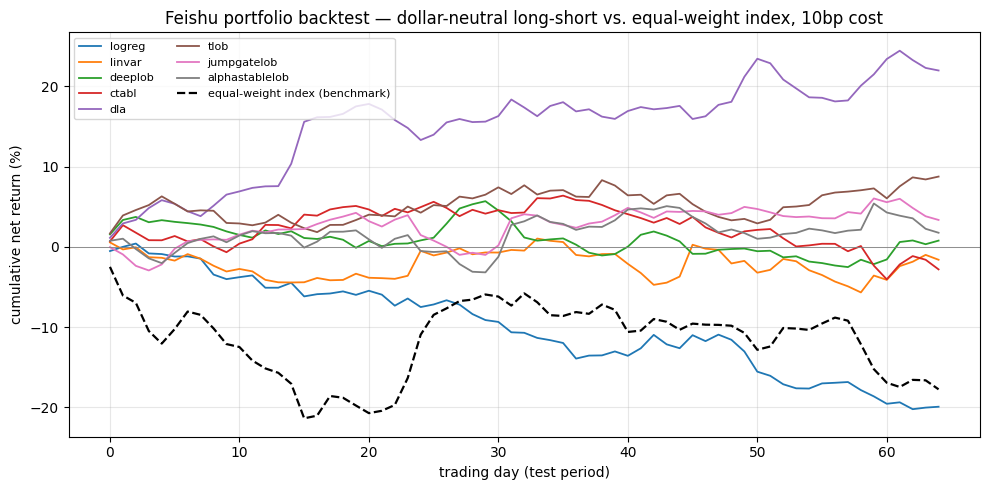

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.get_cmap("tab10")
i = 0
for tag, daily in CURVES.items():
    if tag == BENCH_TAG:
        continue
    ax.plot(np.arange(len(daily)), np.cumsum(daily["net"]) * 100,
            lw=1.3, color=cmap(i % 10), label=DISPLAY[tag])
    i += 1
ax.plot(np.arange(len(CURVES[BENCH_TAG])), np.cumsum(CURVES[BENCH_TAG]["net"]) * 100,
        "k--", lw=1.6, label="equal-weight index (benchmark)")
ax.axhline(0, color="gray", lw=0.6)
ax.set_xlabel("trading day (test period)")
ax.set_ylabel("cumulative net return (%)")
ax.set_title(f"Feishu portfolio backtest — dollar-neutral long-short vs. equal-weight index, "
             f"{COST_BPS:.0f}bp cost")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Reading the results

- **`mean_IC`** is the honest signal-quality column — it should track `sharpe`
  closely. A model with negative IC has a signal that is anti-correlated with
  forward returns on this universe: its long-short book *loses* systematically,
  regardless of how good its classification accuracy looked in isolation.
- **`turnover`** matters for cost: a model that earns the same return with
  lower turnover is cheaper to run and more robust to worse execution than the
  assumed `COST_BPS`.
- **`max_dd_%`** vs `ann_return_%` gives a feel for how bumpy the ride is, not
  just the average.
- **`equal_weight_index`** is the passive long-only benchmark (1/N every asset, same cost model). A model that doesn't beat it on Sharpe/return isn't adding value over simply holding the universe — check this row first before crediting any model with skill.
- Re-run with a different `COST_BPS` (§2) to see how sensitive the ranking is
  to trading costs — a ranking that flips at a slightly higher cost is not a
  robust ranking.

## 8. Alternative strategy — threshold buy/sell with flat-position decay

The strategy in §5 is *continuous*: the weight is proportional to the demeaned
score every day, so a small change in conviction produces a small change in
position. Here is a more discretionary, rule-based alternative:

- **score above its buy threshold** → target position = **full long** (+1).
- **score below its sell threshold** → target position = **full short** (−1).
- **otherwise ("flat" / low-conviction zone)** → **decay whatever position you
  currently hold by `FLAT_DECAY`** (default 50%) rather than closing it
  outright or holding it at full size — i.e. *if you have a position and the
  signal goes flat, sell half of it*.

Positions persist across days (this strategy has memory — the flat-decay rule
only makes sense relative to yesterday's holding), then the day's raw
positions are gross-normalised (`Σ|w| = 1`) so the book is comparable in scale
to §5, and the **same cost/turnover model** applies. Because model score
scales differ enormously (e.g. a collapsed classifier's scores cluster near 0
while a confident linear model spans most of `[-1, 1]`), the buy/sell
thresholds are **quantiles of that model's own score distribution** on the
backtest window, not a fixed absolute number — `BUY_Q`/`SELL_Q` are the
config knobs.

In [24]:
BUY_Q = 0.70       # score above this quantile of the model's own scores -> full long
SELL_Q = 0.30      # score below this quantile -> full short
FLAT_DECAY = 0.50  # otherwise: decay any existing position by this fraction ("sell half")


def threshold_portfolio(bt, score, pred, cost_bps=COST_BPS,
                        buy_q=BUY_Q, sell_q=SELL_Q, flat_decay=FLAT_DECAY):
    """Rule-based long/flat/short strategy with position decay in the flat zone.

    Per asset, per day:
      score > buy_thresh   -> target position = +1  (full long)
      score < sell_thresh  -> target position = -1  (full short)
      otherwise ("flat")   -> target position = previous position * (1 - flat_decay)
                              i.e. sell `flat_decay` of whatever you currently hold
    buy_thresh/sell_thresh are quantiles of THIS model's own score distribution
    on the backtest window, so the rule is comparable across models with very
    different score scales. Positions are gross-normalised (Σ|w|=1) each day;
    cost is charged on turnover exactly as in `portfolio()`.
    """
    df = bt.assign(score=score, pred=pred).dropna(subset=["fwd_ret", "score"])
    buy_thresh = np.quantile(df["score"], buy_q)
    sell_thresh = np.quantile(df["score"], sell_q)

    daily, prev_w, pos = [], pd.Series(dtype=float), {}
    for d in sorted(df["date"].unique()):
        g = df[df["date"] == d]
        s = g.set_index("asset")["score"]
        r = g.set_index("asset")["fwd_ret"]
        raw = {}
        for a, sc in s.items():
            prior = pos.get(a, 0.0)
            if sc > buy_thresh:
                raw[a] = 1.0
            elif sc < sell_thresh:
                raw[a] = -1.0
            else:
                raw[a] = prior * (1.0 - flat_decay)   # flat: sell half of any existing position
            pos[a] = raw[a]
        w = pd.Series(raw)
        gross = w.abs().sum()
        if gross > 0:
            w = w / gross
        r_gross = float((w * r).sum())
        idx = w.index.union(prev_w.index)
        turnover = float(
            (w.reindex(idx, fill_value=0.0) - prev_w.reindex(idx, fill_value=0.0))
            .abs().sum()
        )
        r_net = r_gross - 0.5 * (cost_bps / 1e4) * turnover
        ic = (float(pd.Series(s.values).corr(pd.Series(r.values), method="spearman"))
              if len(s) >= 3 else np.nan)
        daily.append({"date": d, "gross": r_gross, "net": r_net,
                      "turnover": turnover, "ic": ic, "n": len(g)})
        prev_w = w
    return pd.DataFrame(daily), buy_thresh, sell_thresh


CURVES_THRESH, ROWS_THRESH = {}, []
for tag, (score, pred) in SCORES.items():
    daily, bthr, sthr = threshold_portfolio(BT, score, pred)
    CURVES_THRESH[tag] = daily
    ROWS_THRESH.append({"model": DISPLAY[tag], **perf(daily)})
    print(f"  {tag:<16} Sharpe={perf(daily)['sharpe']:+.2f}  "
          f"(buy>{bthr:+.3f}, sell<{sthr:+.3f})")

CURVES_THRESH[BENCH_TAG] = CURVES[BENCH_TAG]          # same passive benchmark
ROWS_THRESH.append({"model": BENCH_TAG, **perf(CURVES[BENCH_TAG])})
summary_thresh = pd.DataFrame(ROWS_THRESH).set_index("model").sort_values("sharpe", ascending=False)

  logreg           Sharpe=-7.40  (buy>+0.159, sell<-0.154)
  linvar           Sharpe=-2.21  (buy>+0.049, sell<-0.079)
  deeplob          Sharpe=-1.07  (buy>+0.002, sell<-0.001)
  ctabl            Sharpe=-1.89  (buy>+0.049, sell<-0.067)
  dla              Sharpe=+4.56  (buy>-0.035, sell<-0.035)
  tlob             Sharpe=+1.48  (buy>+0.060, sell<+0.047)
  jumpgatelob      Sharpe=+1.09  (buy>-0.000, sell<-0.020)
  alphastablelob   Sharpe=-0.46  (buy>+0.032, sell<-0.020)


## 9. Threshold-strategy results

In [25]:
print(f"=== threshold strategy summary (sorted by net Sharpe, {COST_BPS:.0f}bp cost) ===")
display(summary_thresh.style.background_gradient(cmap="RdYlGn", subset=["sharpe", "mean_IC"])
        .format({"days": "{:.0f}", "ann_return_%": "{:.1f}", "ann_vol_%": "{:.1f}",
                 "sharpe": "{:.2f}", "max_dd_%": "{:.1f}", "hit_%": "{:.0f}",
                 "turnover": "{:.2f}", "mean_IC": "{:.3f}", "net_bp/day": "{:.2f}"}))

=== threshold strategy summary (sorted by net Sharpe, 10bp cost) ===


,days,ann_return_%,ann_vol_%,sharpe,max_dd_%,hit_%,turnover,mean_IC,net_bp/day
model,,,,,,,,,
dla,65,93.8,20.6,4.56,5.7,62,0.28,0.106,38.76
tlob,65,22.1,15.0,1.48,7.9,54,1.03,0.057,9.13
jumpgatelob,65,16.2,14.9,1.09,6.2,54,0.22,0.035,6.70
alphastablelob,65,-7.3,15.7,-0.46,10.3,51,0.35,0.019,-3.01
deeplob,65,-14.5,13.5,-1.07,8.4,45,0.59,0.019,-5.97
ctabl,65,-27.0,14.3,-1.89,10.7,43,0.97,-0.029,-11.16
linvar,65,-33.4,15.1,-2.21,11.8,37,1.02,-0.038,-13.79
equal_weight_index,65,-66.0,26.3,-2.51,18.9,37,0.02,nan,-27.29
logreg,65,-107.8,14.6,-7.40,31.9,28,0.99,-0.035,-44.55


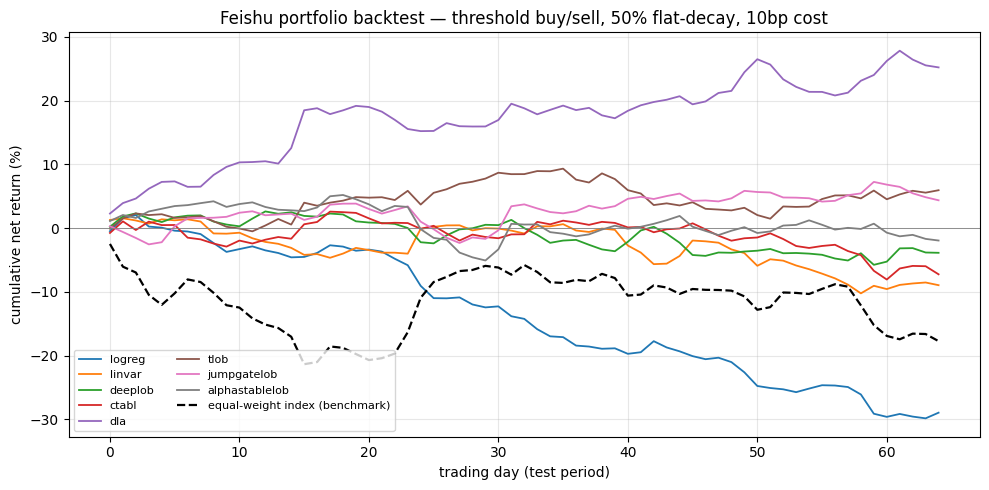

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.get_cmap("tab10")
i = 0
for tag, daily in CURVES_THRESH.items():
    if tag == BENCH_TAG:
        continue
    ax.plot(np.arange(len(daily)), np.cumsum(daily["net"]) * 100,
            lw=1.3, color=cmap(i % 10), label=DISPLAY[tag])
    i += 1
ax.plot(np.arange(len(CURVES_THRESH[BENCH_TAG])),
        np.cumsum(CURVES_THRESH[BENCH_TAG]["net"]) * 100,
        "k--", lw=1.6, label="equal-weight index (benchmark)")
ax.axhline(0, color="gray", lw=0.6)
ax.set_xlabel("trading day (test period)")
ax.set_ylabel("cumulative net return (%)")
ax.set_title(f"Feishu portfolio backtest — threshold buy/sell, {int(FLAT_DECAY*100)}% "
             f"flat-decay, {COST_BPS:.0f}bp cost")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Comparing the two strategies

Same models, same cost model, same test period, same benchmark — only the
position-sizing rule differs. A model whose Sharpe **survives** (or improves)
under the discrete, memory-dependent threshold rule has a signal that is
robust to *how* it's turned into positions; a model that only looks good under
one strategy is more likely fitting the strategy's mechanics than carrying
real information.

In [27]:
cmp = pd.concat([
    summary["sharpe"].rename("sharpe_dollar_neutral"),
    summary_thresh["sharpe"].rename("sharpe_threshold_decay"),
], axis=1)
cmp["Δ (threshold − dollar_neutral)"] = (
    cmp["sharpe_threshold_decay"] - cmp["sharpe_dollar_neutral"]
)
display(cmp.sort_values("sharpe_threshold_decay", ascending=False)
        .style.background_gradient(cmap="RdYlGn", axis=None).format("{:.2f}"))

,sharpe_dollar_neutral,sharpe_threshold_decay,Δ (threshold − dollar_neutral)
model,,,
dla,4.15,4.56,0.41
tlob,2.40,1.48,-0.93
jumpgatelob,0.94,1.09,0.15
alphastablelob,0.41,-0.46,-0.87
deeplob,0.23,-1.07,-1.30
ctabl,-0.75,-1.89,-1.14
linvar,-0.38,-2.21,-1.83
equal_weight_index,-2.51,-2.51,0.00
logreg,-5.77,-7.40,-1.64
